=== ZND reference ===
D_CJ                       = 6.415008470922
reaction length (10%-90%) = 40.70515646
reaction length (5%-95%)  = 55.90595739
s(lambda=0.5)             = 13.84532009
s(lambda=0.9)             = 43.20641311
q_end/c_end               = 0.999996709958

=== Front-speed sensitivity to fitting window ===
------------------------------------------------------------------------------------------
   t_fit_min        D_shock       D_lambda           D_CJ     D_shock-D_CJ      shock_rms     lambda_rms
------------------------------------------------------------------------------------------
       8.000     6.60295163     6.68088395     6.41500847       0.18794316   1.230522e+00   2.392528e+00
      10.000     6.63562944     6.76350603     6.41500847       0.22062097   1.070390e+00   1.759537e+00
      12.000     6.66814610     6.83639843     6.41500847       0.25313763   9.194686e-01   1.174361e+00
      15.000     6.71633462     6.91451141     6.41500847       0.30132615   7

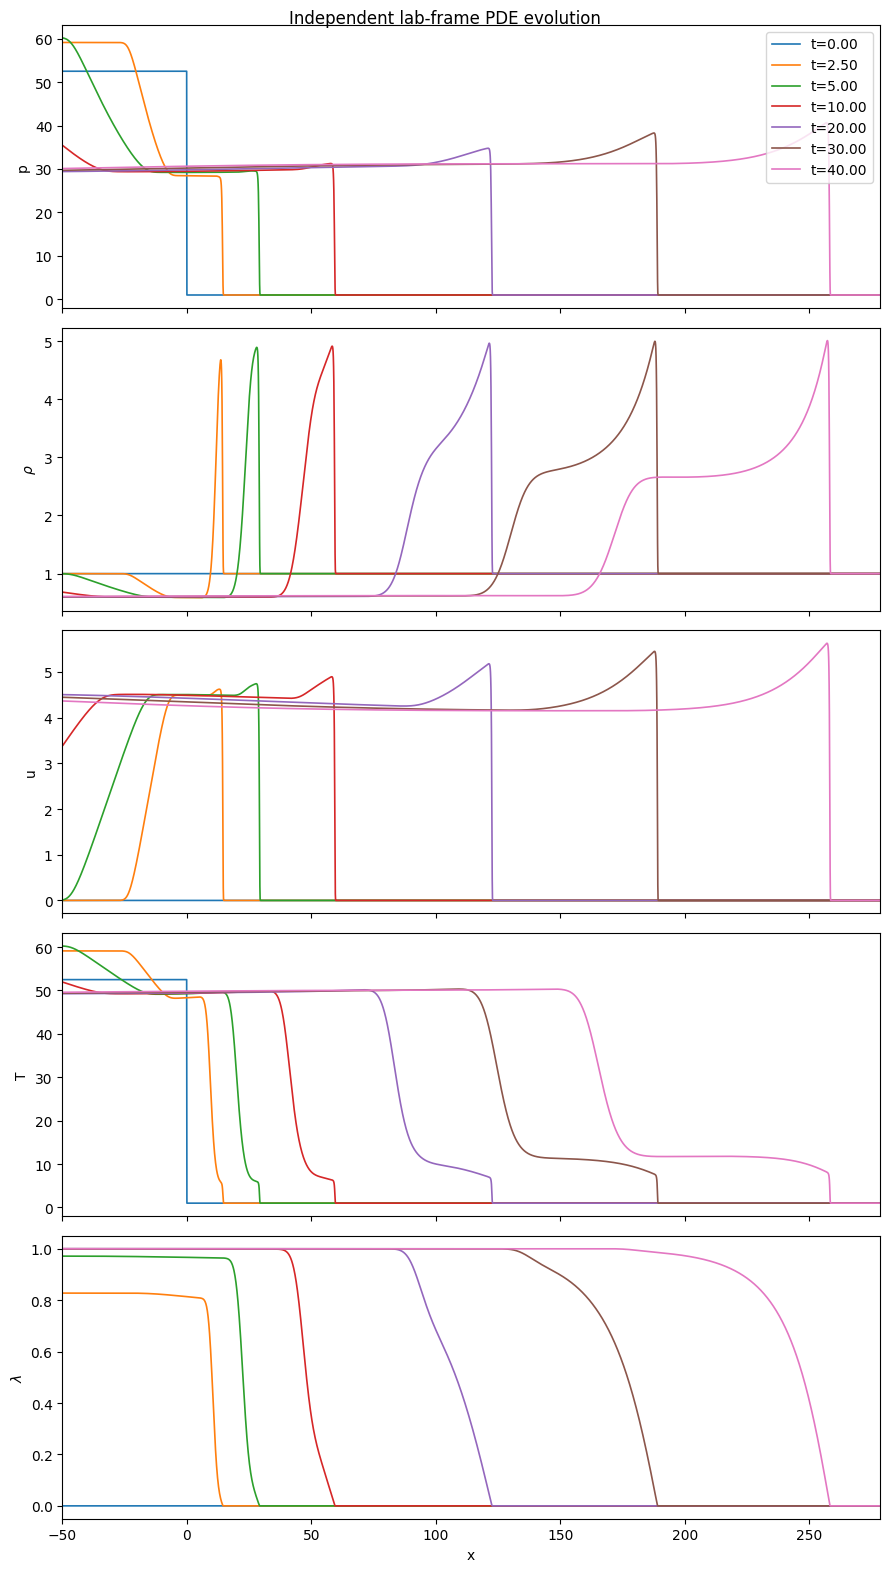

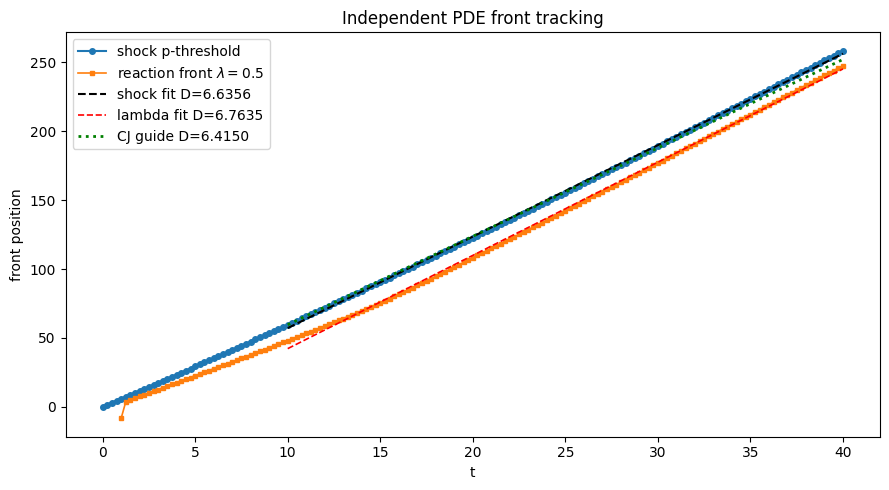

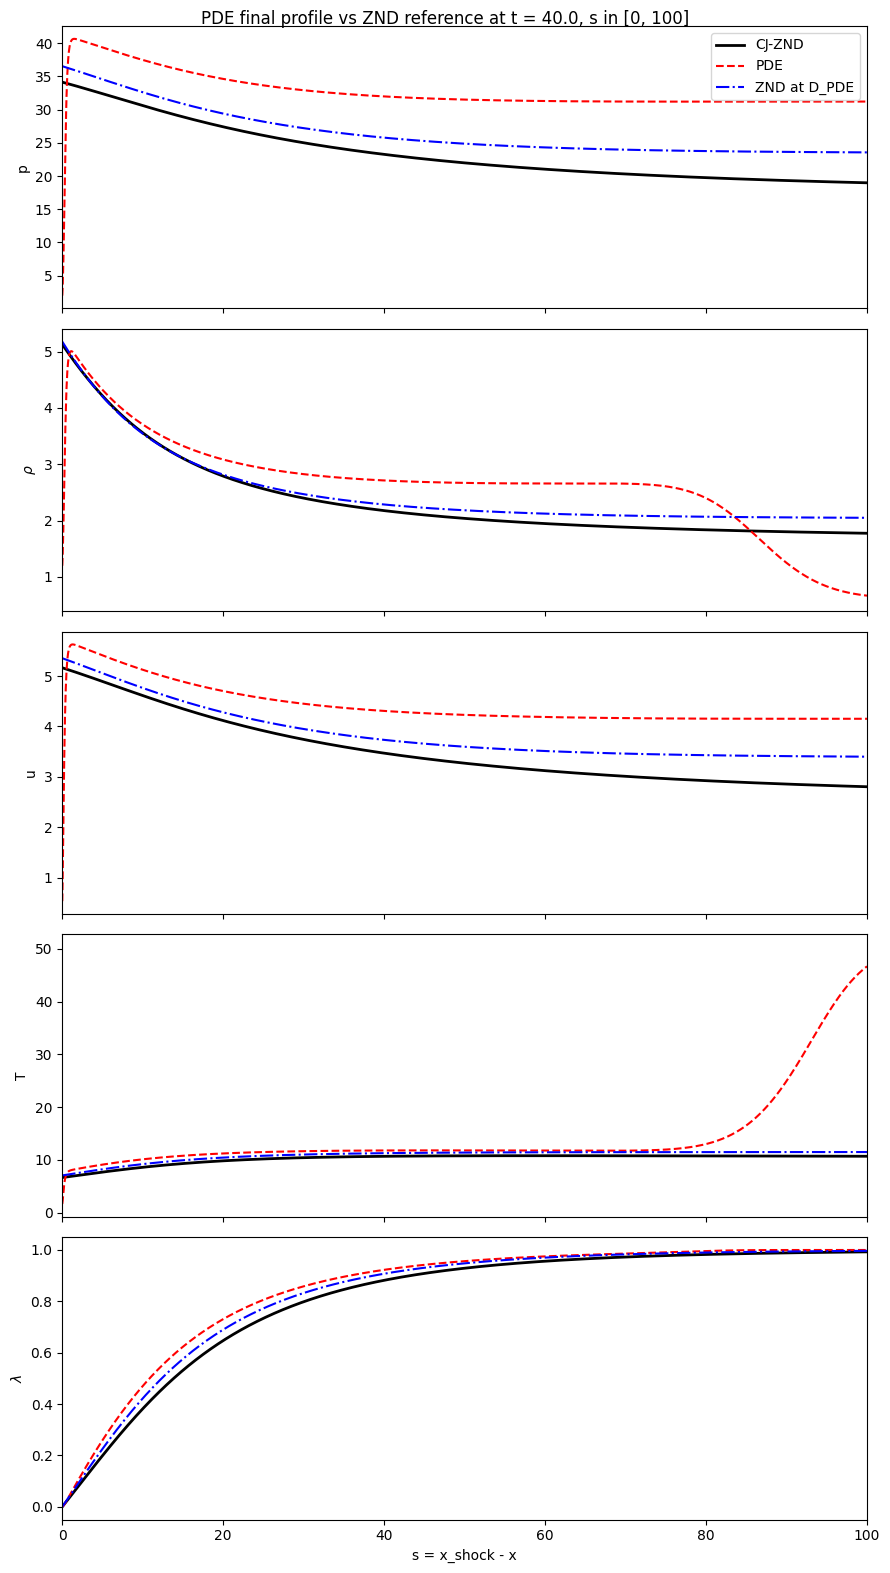

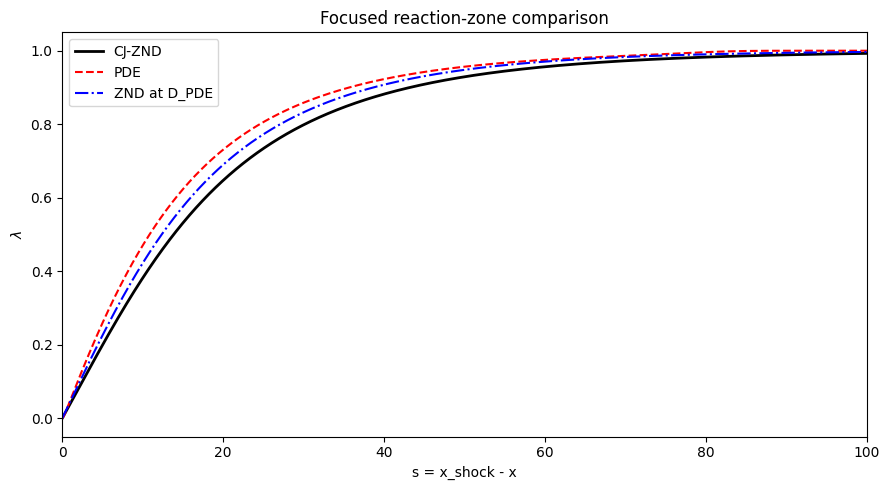

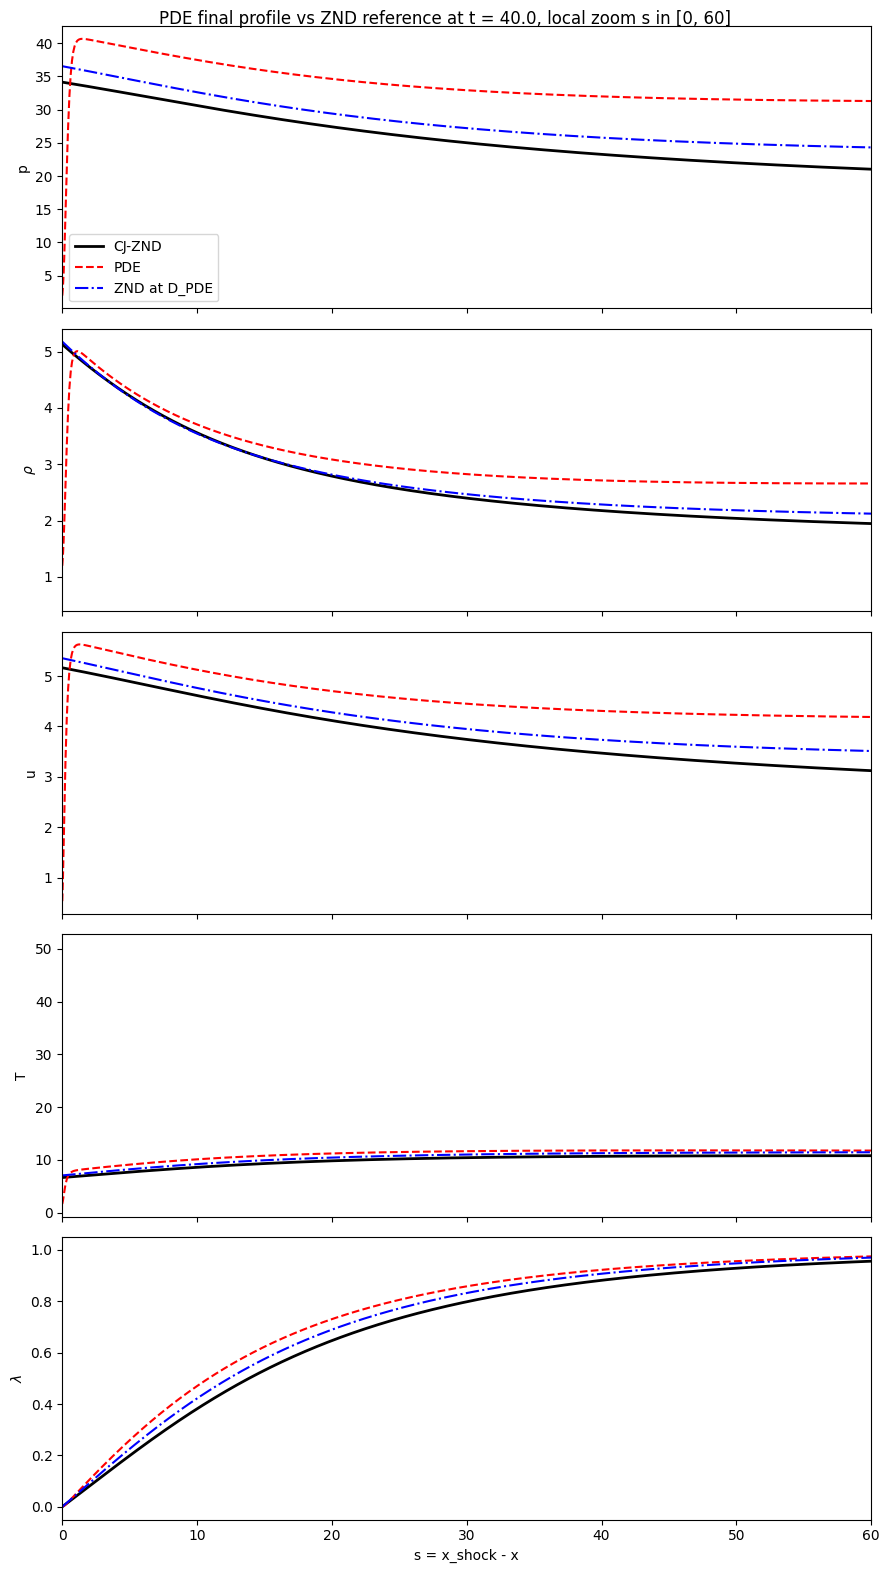

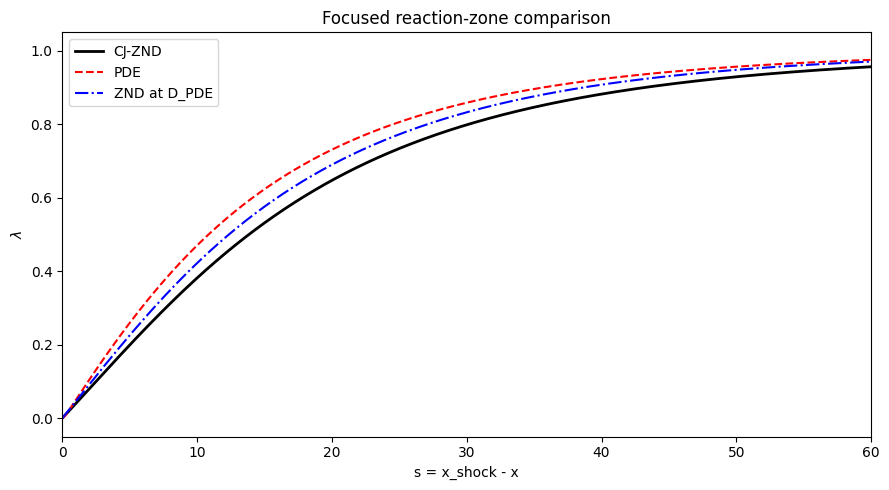


=== Independent ignition driver sweep ===
----------------------------------------------------------------------------------------------------------------
     p_ign        D_shock       D_lambda           D_CJ     D_shock-D_CJ      shock_rms     lambda_rms
----------------------------------------------------------------------------------------------------------------
    50.000       6.173016       5.733783       6.415008        -0.241992   1.531798e-01   4.777902e-01
    52.500       6.314814       5.943341       6.415008        -0.100195   1.617029e-01   5.174401e-01
    55.000       6.451433       6.144400       6.415008         0.036425   1.656982e-01   5.404412e-01
    57.500       6.585150       6.335109       6.415008         0.170142   1.699229e-01   5.473271e-01
    60.000       6.714682       6.514732       6.415008         0.299674   1.745459e-01   5.405352e-01
    62.500       6.840611       6.683330       6.415008         0.425602   1.766498e-01   5.234932e-01
----------

In [ ]:
# CLASSICAL SOLVER
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import math




class ZNDFailure(Exception):
    def __init__(self, lam_fail, last_state=None, message="ZND profile terminated before lam_end"):
        super().__init__(message)
        self.lam_fail = lam_fail
        self.last_state = last_state


@dataclass
class Params:
    gamma: float = 1.4
    Q: float = 20.0
    k: float = 1.0
    Ea: float = 20.0
    R: float = 1.0

    rho_a: float = 1.0
    u_a: float = 0.0
    p_a: float = 1.0
    lam_a: float = 0.0

    n_lam: int = 4000
    lam_end: float = 1.0 - 1.0e-6

    D_bracket_low: float = 1.3
    D_bracket_high: float = 7.0
    cj_tol: float = 1.0e-10
    cj_max_iter: int = 80


def reaction_rate_znd(lam, T, p: Params):
    return p.k * (1.0 - lam) * np.exp(-p.Ea / (p.R * T))


def shock_jump(par: Params, D):
    c_a = math.sqrt(par.gamma * par.p_a / par.rho_a)
    q_a = D - par.u_a

    if q_a <= c_a:
        raise ValueError("D is too small: upstream state is not supersonic relative to the shock.")

    M_a = q_a / c_a

    rho_n = par.rho_a * ((par.gamma + 1.0) * M_a**2) / (
        (par.gamma - 1.0) * M_a**2 + 2.0
    )

    p_n = par.p_a * (
        1.0 + 2.0 * par.gamma / (par.gamma + 1.0) * (M_a**2 - 1.0)
    )

    q_n = q_a * par.rho_a / rho_n
    u_n = D - q_n
    lam_n = par.lam_a

    m = rho_n * q_n
    P = p_n + rho_n * q_n**2

    B = (
        par.gamma / (par.gamma - 1.0) * (p_n / rho_n)
        - par.Q * lam_n
        + 0.5 * q_n**2
    )

    T_n = p_n / (rho_n * par.R)
    c_n = math.sqrt(par.gamma * p_n / rho_n)

    vn = {
        "rho": rho_n,
        "u": u_n,
        "q": q_n,
        "p": p_n,
        "T": T_n,
        "c": c_n,
        "lam": lam_n,
    }

    inv = {"m": m, "P": P, "B": B}

    return vn, inv


def state_from_lambda(lam, inv, par: Params, D, v_prev):
    m = inv["m"]
    P = inv["P"]
    B = inv["B"]

    a = m**2 * (par.gamma + 1.0) / (2.0 * (par.gamma - 1.0))
    b = -par.gamma * P / (par.gamma - 1.0)
    c = B + par.Q * lam

    disc = b**2 - 4.0 * a * c

    if disc < 0.0:
        raise ZNDFailure(lam_fail=lam, last_state=None)

    sqrt_disc = math.sqrt(disc)

    roots = [
        (-b - sqrt_disc) / (2.0 * a),
        (-b + sqrt_disc) / (2.0 * a),
    ]

    candidates = []

    for v in roots:
        if v <= 0.0:
            continue

        rho = 1.0 / v
        q = m * v
        p = P - m**2 * v

        if rho > 0.0 and q > 0.0 and p > 0.0:
            candidates.append(v)

    if not candidates:
        raise ZNDFailure(lam_fail=lam, last_state=None)

    v = min(candidates, key=lambda x: abs(x - v_prev))

    rho = 1.0 / v
    q = m * v
    u = D - q
    p = P - m**2 * v
    T = p / (rho * par.R)
    c = math.sqrt(par.gamma * p / rho)
    M_rel = q / c
    omega = reaction_rate_znd(lam, T, par)

    return {
        "rho": rho,
        "u": u,
        "q": q,
        "p": p,
        "T": T,
        "c": c,
        "M_rel": M_rel,
        "omega": omega,
        "v": v,
    }


def build_znd_profile(par: Params, D):
    vn, inv = shock_jump(par, D)

    lam = np.linspace(par.lam_a, par.lam_end, par.n_lam)

    rho = np.empty_like(lam)
    u = np.empty_like(lam)
    q = np.empty_like(lam)
    p = np.empty_like(lam)
    T = np.empty_like(lam)
    c = np.empty_like(lam)
    M_rel = np.empty_like(lam)
    omega = np.empty_like(lam)
    s = np.empty_like(lam)

    v_prev = 1.0 / vn["rho"]
    last_state = None

    for i, lam_i in enumerate(lam):
        try:
            st = state_from_lambda(lam_i, inv, par, D, v_prev)
        except ZNDFailure:
            raise ZNDFailure(lam_fail=lam_i, last_state=last_state)

        v_prev = st["v"]
        last_state = st

        rho[i] = st["rho"]
        u[i] = st["u"]
        q[i] = st["q"]
        p[i] = st["p"]
        T[i] = st["T"]
        c[i] = st["c"]
        M_rel[i] = st["M_rel"]
        omega[i] = st["omega"]

    ds_dlam = q / omega

    s[0] = 0.0

    for i in range(1, len(lam)):
        dlam = lam[i] - lam[i - 1]
        s[i] = s[i - 1] + 0.5 * (ds_dlam[i] + ds_dlam[i - 1]) * dlam

    m_prof = rho * q
    P_prof = p + rho * q**2

    B_prof = (
        par.gamma / (par.gamma - 1.0) * (p / rho)
        - par.Q * lam
        + 0.5 * q**2
    )

    s_lam_005 = np.interp(0.05, lam, s)
    s_lam_010 = np.interp(0.10, lam, s)
    s_lam_050 = np.interp(0.50, lam, s)
    s_lam_090 = np.interp(0.90, lam, s)
    s_lam_095 = np.interp(0.95, lam, s)

    out = {
        "D": D,
        "s": s,
        "lam": lam,
        "rho": rho,
        "u": u,
        "q": q,
        "p": p,
        "T": T,
        "c": c,
        "M_rel": M_rel,
        "omega": omega,
        "vn_state": vn,
        "invariants": inv,
        "m_prof": m_prof,
        "P_prof": P_prof,
        "B_prof": B_prof,
        "reaction_length_10_90": s_lam_090 - s_lam_010,
        "reaction_length_5_95": s_lam_095 - s_lam_005,
        "reaction_length_total": s[-1],
        "s_lam_05": s_lam_050,
        "s_lam_09": s_lam_090,
        "p_max": np.max(p),
        "T_max": np.max(T),
        "q_end_over_c_end": M_rel[-1],
        "s_at_p_max": s[np.argmax(p)],
        "s_at_T_max": s[np.argmax(T)],
    }

    return out


def try_build_profile(par: Params, D):
    try:
        prof = build_znd_profile(par, D)
        return True, prof, None
    except Exception as e:
        return False, None, e


def find_cj_speed(par: Params):
    c_a = math.sqrt(par.gamma * par.p_a / par.rho_a)
    Dmin = c_a * (1.0 + 1.0e-12)

    D_low = max(par.D_bracket_low, Dmin)
    D_high = max(par.D_bracket_high, 1.1 * D_low)

    ok_low, _, _ = try_build_profile(par, D_low)

    while ok_low and D_low > Dmin * 1.000001:
        D_low = 0.5 * (D_low + Dmin)
        ok_low, _, _ = try_build_profile(par, D_low)

    if ok_low:
        raise RuntimeError("Could not find a failing lower bracket for CJ search.")

    ok_high, prof_high, _ = try_build_profile(par, D_high)

    while not ok_high:
        D_high *= 1.2
        ok_high, prof_high, _ = try_build_profile(par, D_high)

    for _ in range(par.cj_max_iter):
        D_mid = 0.5 * (D_low + D_high)
        ok_mid, prof_mid, _ = try_build_profile(par, D_mid)

        if ok_mid:
            D_high = D_mid
            prof_high = prof_mid
        else:
            D_low = D_mid

        if abs(D_high - D_low) <= par.cj_tol * max(1.0, abs(D_high)):
            break

    return {
        "D_cj": D_high,
        "D_fail": D_low,
        "D_succeed": D_high,
        "profile": prof_high,
    }



# Laboratory-frame PDE solver: LLF/Rusanov + SSP-RK3 + Strang


def prim_to_cons(rho, u, p, lam, gamma, Q):
    rho = np.asarray(rho)
    u = np.asarray(u)
    p = np.asarray(p)
    lam = np.asarray(lam)

    z = rho * lam

    E = p / (gamma - 1.0) + 0.5 * rho * u**2 - Q * z

    return np.column_stack((rho, rho * u, E, z))


def cons_to_prim(U, gamma, Q):
    rho = U[:, 0]
    mom = U[:, 1]
    E = U[:, 2]
    z = U[:, 3]

    if np.any(rho <= 0.0):
        raise ValueError(f"Non-positive density encountered: min(rho) = {rho.min()}")

    u = mom / rho
    lam = z / rho

    p = (gamma - 1.0) * (E - 0.5 * mom**2 / rho + Q * z)

    if np.any(p <= 0.0):
        raise ValueError(f"Non-positive pressure encountered: min(p) = {p.min()}")

    return rho, u, p, lam


def flux(U, gamma, Q):
    rho, u, p, _ = cons_to_prim(U, gamma, Q)

    mom = U[:, 1]
    E = U[:, 2]
    z = U[:, 3]

    F = np.empty_like(U)

    F[:, 0] = mom
    F[:, 1] = mom * u + p
    F[:, 2] = u * (E + p)
    F[:, 3] = u * z

    return F


def temperature_from_prim(rho, p, Rgas):
    return p / (rho * Rgas)


def reaction_rate_from_prim(rho, p, lam, k, Ea, Rgas):
    T = np.maximum(p / (rho * Rgas), 1.0e-14)
    lam_clip = np.clip(lam, 0.0, 1.0)

    return k * (1.0 - lam_clip) * np.exp(-Ea / (Rgas * T))


def apply_outflow_bc(U):
    U[0, :] = U[1, :]
    U[-1, :] = U[-2, :]


def rhs_euler_llf(U, dx, gamma, Q):
    Uc = U.copy()
    apply_outflow_bc(Uc)

    UL = Uc[:-1, :]
    UR = Uc[1:, :]

    FL = flux(UL, gamma, Q)
    FR = flux(UR, gamma, Q)

    rhoL, uL, pL, _ = cons_to_prim(UL, gamma, Q)
    rhoR, uR, pR, _ = cons_to_prim(UR, gamma, Q)

    cL = np.sqrt(gamma * pL / rhoL)
    cR = np.sqrt(gamma * pR / rhoR)

    a = np.maximum(np.abs(uL) + cL, np.abs(uR) + cR)[:, None]

    Fhat = 0.5 * (FL + FR) - 0.5 * a * (UR - UL)

    rhs = np.zeros_like(Uc)
    rhs[1:-1, :] = -(Fhat[1:, :] - Fhat[:-1, :]) / dx

    return rhs


def max_wave_speed(U, gamma, Q):
    rho, u, p, _ = cons_to_prim(U[1:-1, :], gamma, Q)
    c = np.sqrt(gamma * p / rho)

    return np.max(np.abs(u) + c)


def compute_dt(U, dx, cfl, gamma, Q):
    amax = max_wave_speed(U, gamma, Q)

    return cfl * dx / amax


def ssprk3_step(U, dt, dx, gamma, Q):
    U0 = U.copy()

    K1 = rhs_euler_llf(U0, dx, gamma, Q)
    U1 = U0.copy()
    U1[1:-1, :] = U0[1:-1, :] + dt * K1[1:-1, :]
    apply_outflow_bc(U1)

    K2 = rhs_euler_llf(U1, dx, gamma, Q)
    U2 = U1.copy()
    U2[1:-1, :] = 0.75 * U0[1:-1, :] + 0.25 * (
        U1[1:-1, :] + dt * K2[1:-1, :]
    )
    apply_outflow_bc(U2)

    K3 = rhs_euler_llf(U2, dx, gamma, Q)
    U3 = U2.copy()
    U3[1:-1, :] = (1.0 / 3.0) * U0[1:-1, :] + (2.0 / 3.0) * (
        U2[1:-1, :] + dt * K3[1:-1, :]
    )
    apply_outflow_bc(U3)

    return U3


def reaction_step(U, dt, gamma, Q, k, Ea, Rgas, react_cfl=0.20, max_substeps=20000):
    Uwork = U.copy()
    apply_outflow_bc(Uwork)

    remaining = dt
    nsub = 0

    while remaining > 1.0e-15:
        rho, u, p, lam = cons_to_prim(Uwork[1:-1, :], gamma, Q)

        omega = reaction_rate_from_prim(rho, p, lam, k, Ea, Rgas)
        omega_max = np.max(omega)

        if omega_max < 1.0e-14:
            break

        dtau = min(remaining, react_cfl / omega_max)

        accepted = False

        for _ in range(20):
            z_old = Uwork[1:-1, 3].copy()
            z_new = z_old + dtau * rho * omega

            lam_new = np.clip(z_new / rho, 0.0, 1.0)
            z_new = rho * lam_new

            Utrial = Uwork.copy()
            Utrial[1:-1, 3] = z_new

            try:
                _ = cons_to_prim(Utrial[1:-1, :], gamma, Q)
                accepted = True
                Uwork = Utrial
                remaining -= dtau
                break
            except ValueError:
                dtau *= 0.5

        if not accepted:
            raise RuntimeError("Reaction step failed to preserve positivity.")

        nsub += 1

        if nsub > max_substeps:
            raise RuntimeError("Too many reaction substeps. Try smaller dt or weaker reaction.")

    apply_outflow_bc(Uwork)

    return Uwork


def strang_step(U, dt, dx, gamma, Q, k, Ea, Rgas, react_cfl=0.20):
    U1 = reaction_step(U, 0.5 * dt, gamma, Q, k, Ea, Rgas, react_cfl=react_cfl)
    U2 = ssprk3_step(U1, dt, dx, gamma, Q)
    U3 = reaction_step(U2, 0.5 * dt, gamma, Q, k, Ea, Rgas, react_cfl=react_cfl)

    return U3



# Independent initial condition


def initialize_independent_ignition(
    x_centers,
    par: Params,
    x_ign_left=-50.0,
    x_ign_right=0.0,
    rho_ign=1.0,
    u_ign=0.0,
    p_ign=52.5,
    lam_ign=0.0,
    smooth=False,
    smooth_width=1.0
):


    rho = par.rho_a * np.ones_like(x_centers)
    u = par.u_a * np.ones_like(x_centers)
    p = par.p_a * np.ones_like(x_centers)
    lam = par.lam_a * np.ones_like(x_centers)

    if not smooth:
        mask = (x_centers >= x_ign_left) & (x_centers <= x_ign_right)

        rho[mask] = rho_ign
        u[mask] = u_ign
        p[mask] = p_ign
        lam[mask] = lam_ign

    else:

        left = 0.5 * (1.0 + np.tanh((x_centers - x_ign_left) / smooth_width))
        right = 0.5 * (1.0 - np.tanh((x_centers - x_ign_right) / smooth_width))
        w = left * right

        rho = (1.0 - w) * rho + w * rho_ign
        u = (1.0 - w) * u + w * u_ign
        p = (1.0 - w) * p + w * p_ign
        lam = (1.0 - w) * lam + w * lam_ign

    return prim_to_cons(rho, u, p, lam, par.gamma, par.Q)


def solve_independent_reactive_llf(
    par: Params,
    xL=-50.0,
    xR=250.0,
    N=3000,
    final_time=30.0,
    cfl=0.20,
    react_cfl=0.20,
    ignition_kwargs=None,
    snapshot_times=None,
    tracking_dt=0.25
):
    dx = (xR - xL) / N

    x_interfaces = np.linspace(xL, xR, N + 1)
    x_centers = 0.5 * (x_interfaces[:-1] + x_interfaces[1:])

    if ignition_kwargs is None:
        ignition_kwargs = {}

    U = np.zeros((N + 2, 4))
    U[1:-1, :] = initialize_independent_ignition(x_centers, par, **ignition_kwargs)
    apply_outflow_bc(U)

    t = 0.0

    snapshots = []
    trajectory = []

    if snapshot_times is not None:
        snapshot_times = sorted(snapshot_times)
        next_snap = 0
    else:
        next_snap = None

    next_track = 0.0

    while t < final_time:
        dt = compute_dt(U, dx, cfl, par.gamma, par.Q)

        if t + dt > final_time:
            dt = final_time - t

        if snapshot_times is not None and next_snap < len(snapshot_times):
            target = snapshot_times[next_snap]

            if t < target <= t + dt:
                dt = target - t

        if t < next_track <= t + dt:
            dt = next_track - t

        U = strang_step(U, dt, dx, par.gamma, par.Q, par.k, par.Ea, par.R, react_cfl=react_cfl)
        t += dt

        if t >= next_track - 1.0e-12:
            xs = shock_position_pressure_threshold(x_centers, U[1:-1, :], par, p_level=2.0)
            xl = lambda_position_level(x_centers, U[1:-1, :], par, level=0.5)

            trajectory.append((t, xs, xl))
            next_track += tracking_dt

        if snapshot_times is not None and next_snap < len(snapshot_times):
            target = snapshot_times[next_snap]

            if abs(t - target) < 1.0e-12 or t > target:
                snapshots.append((t, U[1:-1, :].copy()))
                next_snap += 1

    return x_centers, U[1:-1, :], snapshots, np.array(trajectory)



# Front tracking and shock-attached extraction


def shock_position_pressure_threshold(x, U, par: Params, p_level=2.0):


    rho, u, p, lam = cons_to_prim(U, par.gamma, par.Q)

    y = p - p_level

    idx = np.where(y[:-1] * y[1:] <= 0.0)[0]

    if len(idx) == 0:
        return np.nan


    i = idx[-1]

    x0, x1 = x[i], x[i + 1]
    y0, y1 = y[i], y[i + 1]

    if abs(y1 - y0) < 1.0e-14:
        return 0.5 * (x0 + x1)

    return x0 - y0 * (x1 - x0) / (y1 - y0)


def lambda_position_level(x, U, par: Params, level=0.5):
    rho, u, p, lam = cons_to_prim(U, par.gamma, par.Q)

    y = lam - level

    idx = np.where(y[:-1] * y[1:] <= 0.0)[0]

    if len(idx) == 0:
        return np.nan


    i = idx[-1]

    x0, x1 = x[i], x[i + 1]
    y0, y1 = y[i], y[i + 1]

    if abs(y1 - y0) < 1.0e-14:
        return 0.5 * (x0 + x1)

    return x0 - y0 * (x1 - x0) / (y1 - y0)


def fit_front_speed(trajectory, t_min=10.0, use_lambda_front=False):


    if trajectory.size == 0:
        return np.nan, np.nan, np.nan, np.empty((0, 2))

    t = trajectory[:, 0]
    x_front = trajectory[:, 2] if use_lambda_front else trajectory[:, 1]

    mask = np.isfinite(x_front) & (t >= t_min)

    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan, np.column_stack((t[mask], x_front[mask]))

    coeff = np.polyfit(t[mask], x_front[mask], 1)
    D_fit = coeff[0]
    b_fit = coeff[1]

    residual = x_front[mask] - (D_fit * t[mask] + b_fit)
    rms = np.sqrt(np.mean(residual**2))

    return D_fit, b_fit, rms, np.column_stack((t[mask], x_front[mask]))


def extract_pde_profile_behind_shock(x, U, par: Params, x_shock, s_max=120.0, n_points=2000):

    rho, u, p, lam = cons_to_prim(U, par.gamma, par.Q)
    T = temperature_from_prim(rho, p, par.R)
    omega = reaction_rate_from_prim(rho, p, lam, par.k, par.Ea, par.R)

    s = np.linspace(0.0, s_max, n_points)
    x_query = x_shock - s


    rho_s = np.interp(x_query, x, rho)
    u_s = np.interp(x_query, x, u)
    p_s = np.interp(x_query, x, p)
    T_s = np.interp(x_query, x, T)
    lam_s = np.interp(x_query, x, lam)
    omega_s = np.interp(x_query, x, omega)

    return {
        "s": s,
        "rho": rho_s,
        "u": u_s,
        "p": p_s,
        "T": T_s,
        "lam": lam_s,
        "omega": omega_s,
    }


def znd_profile_on_s_grid(prof, s_grid):
    return {
        "s": s_grid,
        "rho": np.interp(s_grid, prof["s"], prof["rho"]),
        "u": np.interp(s_grid, prof["s"], prof["u"]),
        "p": np.interp(s_grid, prof["s"], prof["p"]),
        "T": np.interp(s_grid, prof["s"], prof["T"]),
        "lam": np.interp(s_grid, prof["s"], prof["lam"]),
        "omega": np.interp(s_grid, prof["s"], prof["omega"]),
    }


def reaction_zone_metrics_from_profile(profile):
    s = profile["s"]
    lam = profile["lam"]

    def pos(level):
        if np.all(lam < level) or np.all(lam > level):
            return np.nan

        idx = np.where((lam[:-1] - level) * (lam[1:] - level) <= 0.0)[0]

        if len(idx) == 0:
            return np.nan

        i = idx[0]
        s0, s1 = s[i], s[i + 1]
        y0, y1 = lam[i], lam[i + 1]

        if abs(y1 - y0) < 1.0e-14:
            return 0.5 * (s0 + s1)

        return s0 + (level - y0) * (s1 - s0) / (y1 - y0)

    s05 = pos(0.05)
    s10 = pos(0.10)
    s50 = pos(0.50)
    s90 = pos(0.90)
    s95 = pos(0.95)

    return {
        "s_lam_005": s05,
        "s_lam_010": s10,
        "s_lam_050": s50,
        "s_lam_090": s90,
        "s_lam_095": s95,
        "L10_90": np.nan if np.isnan(s10) or np.isnan(s90) else s90 - s10,
        "L5_95": np.nan if np.isnan(s05) or np.isnan(s95) else s95 - s05,
    }


def l1_error_on_s(num, ref, s):
    ds = s[1] - s[0]
    return np.sum(np.abs(num - ref)) * ds


def l2_error_on_s(num, ref, s):
    ds = s[1] - s[0]
    return np.sqrt(np.sum((num - ref) ** 2) * ds)


def profile_error_report(pde_prof, znd_prof, smooth_window=(1.0, 80.0)):
    s = pde_prof["s"]

    full = np.ones_like(s, dtype=bool)
    smooth = (s >= smooth_window[0]) & (s <= smooth_window[1])

    def pack(var, mask):
        return {
            "L1": l1_error_on_s(pde_prof[var][mask], znd_prof[var][mask], s[mask]),
            "L2": l2_error_on_s(pde_prof[var][mask], znd_prof[var][mask], s[mask]),
            "Linf": np.max(np.abs(pde_prof[var][mask] - znd_prof[var][mask])),
        }

    return {
        "p_full": pack("p", full),
        "rho_full": pack("rho", full),
        "u_full": pack("u", full),
        "T_full": pack("T", full),
        "lam_full": pack("lam", full),
        "p_smooth": pack("p", smooth),
        "rho_smooth": pack("rho", smooth),
        "u_smooth": pack("u", smooth),
        "T_smooth": pack("T", smooth),
        "lam_smooth": pack("lam", smooth),
    }



# Plotting


def plot_lab_snapshots(x, snapshots, par: Params, xlim=None):
    fig, axes = plt.subplots(5, 1, figsize=(9, 16), sharex=True)

    for t, U in snapshots:
        rho, u, p, lam = cons_to_prim(U, par.gamma, par.Q)
        T = temperature_from_prim(rho, p, par.R)

        axes[0].plot(x, p, lw=1.2, label=f"t={t:.2f}")
        axes[1].plot(x, rho, lw=1.2)
        axes[2].plot(x, u, lw=1.2)
        axes[3].plot(x, T, lw=1.2)
        axes[4].plot(x, lam, lw=1.2)

    axes[0].set_ylabel("p")
    axes[1].set_ylabel(r"$\rho$")
    axes[2].set_ylabel("u")
    axes[3].set_ylabel("T")
    axes[4].set_ylabel(r"$\lambda$")
    axes[4].set_xlabel("x")

    axes[0].legend()

    if xlim is not None:
        for ax in axes:
            ax.set_xlim(xlim)

    fig.suptitle("Independent lab-frame PDE evolution")
    plt.tight_layout()
    plt.show()


def plot_front_trajectory(trajectory, D_cj, t_fit_min=10.0):
    D_s, b_s, rms_s, data_s = fit_front_speed(trajectory, t_min=t_fit_min, use_lambda_front=False)
    D_l, b_l, rms_l, data_l = fit_front_speed(trajectory, t_min=t_fit_min, use_lambda_front=True)

    t = trajectory[:, 0]
    xs = trajectory[:, 1]
    xl = trajectory[:, 2]

    plt.figure(figsize=(9, 5))

    plt.plot(t, xs, "o-", lw=1.5, ms=4, label="shock p-threshold")
    plt.plot(t, xl, "s-", lw=1.2, ms=3, label=r"reaction front $\lambda=0.5$")

    if np.isfinite(D_s):
        tt = np.linspace(np.nanmin(data_s[:, 0]), np.nanmax(data_s[:, 0]), 200)
        plt.plot(tt, D_s * tt + b_s, "k--", lw=1.5, label=f"shock fit D={D_s:.4f}")

    if np.isfinite(D_l):
        tt = np.linspace(np.nanmin(data_l[:, 0]), np.nanmax(data_l[:, 0]), 200)
        plt.plot(tt, D_l * tt + b_l, "r--", lw=1.2, label=f"lambda fit D={D_l:.4f}")

    mask = np.isfinite(xs) & (t >= t_fit_min)

    if np.any(mask):
        t0 = t[mask][0]
        x0 = xs[mask][0]
        tt = np.linspace(t0, np.nanmax(t), 200)
        plt.plot(tt, x0 + D_cj * (tt - t0), "g:", lw=2, label=f"CJ guide D={D_cj:.4f}")

    plt.xlabel("t")
    plt.ylabel("front position")
    plt.title("Independent PDE front tracking")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_pde_vs_znd_profile(pde_prof, znd_cj, znd_speed=None, title_suffix="", xlim=(0.0, 100.0)):
    s = pde_prof["s"]

    fig, axes = plt.subplots(5, 1, figsize=(9, 16), sharex=True)

    variables = ["p", "rho", "u", "T", "lam"]
    labels = ["p", r"$\rho$", "u", "T", r"$\lambda$"]

    for ax, var, lab in zip(axes, variables, labels):
        ax.plot(s, znd_cj[var], "k-", lw=2, label="CJ-ZND")
        ax.plot(s, pde_prof[var], "r--", lw=1.5, label="PDE")

        if znd_speed is not None:
            ax.plot(s, znd_speed[var], "b-.", lw=1.5, label="ZND at D_PDE")

        ax.set_ylabel(lab)

    axes[0].legend()
    axes[-1].set_xlabel("s = x_shock - x")

    if xlim is not None:
        for ax in axes:
            ax.set_xlim(xlim)

    fig.suptitle(f"PDE final profile vs ZND reference {title_suffix}")
    plt.tight_layout()
    plt.show()


def plot_lambda_profile_focus(pde_prof, znd_cj, znd_speed=None, xlim=(0.0, 100.0)):
    s = pde_prof["s"]

    plt.figure(figsize=(9, 5))
    plt.plot(s, znd_cj["lam"], "k-", lw=2, label="CJ-ZND")
    plt.plot(s, pde_prof["lam"], "r--", lw=1.5, label="PDE")

    if znd_speed is not None:
        plt.plot(s, znd_speed["lam"], "b-.", lw=1.5, label="ZND at D_PDE")

    plt.xlabel("s = x_shock - x")
    plt.ylabel(r"$\lambda$")
    plt.title("Focused reaction-zone comparison")
    plt.xlim(xlim)
    plt.legend()
    plt.tight_layout()
    plt.show()



# Driver sweep


def independent_driver_sweep(
    par: Params,
    cj,
    p_ign_values,
    xL,
    xR,
    N,
    final_time,
    cfl,
    react_cfl,
    t_fit_min,
    base_ignition_kwargs
):
    print("\n=== Independent ignition driver sweep ===")
    print("-" * 112)
    print(
        f"{'p_ign':>10} {'D_shock':>14} {'D_lambda':>14} "
        f"{'D_CJ':>14} {'D_shock-D_CJ':>16} "
        f"{'shock_rms':>14} {'lambda_rms':>14}"
    )
    print("-" * 112)

    rows = []

    for p_ign in p_ign_values:
        ignition_kwargs = dict(base_ignition_kwargs)
        ignition_kwargs["p_ign"] = p_ign

        x, U, snapshots, traj = solve_independent_reactive_llf(
            par=par,
            xL=xL,
            xR=xR,
            N=N,
            final_time=final_time,
            cfl=cfl,
            react_cfl=react_cfl,
            ignition_kwargs=ignition_kwargs,
            snapshot_times=None,
            tracking_dt=0.25
        )

        D_s, b_s, rms_s, _ = fit_front_speed(traj, t_min=t_fit_min, use_lambda_front=False)
        D_l, b_l, rms_l, _ = fit_front_speed(traj, t_min=t_fit_min, use_lambda_front=True)

        row = (p_ign, D_s, D_l, cj["D_cj"], D_s - cj["D_cj"], rms_s, rms_l)
        rows.append(row)

        print(
            f"{p_ign:10.3f} {D_s:14.6f} {D_l:14.6f} "
            f"{cj['D_cj']:14.6f} {D_s - cj['D_cj']:16.6f} "
            f"{rms_s:14.6e} {rms_l:14.6e}"
        )

    print("-" * 112)

    return rows



# Main


def main():
    # ---------- small local printer for windowed errors ----------
    def print_window_error_table(title, errs):

        print(f"\n{title}")
        print("-" * 86)
        print(
            f"{'var':>6} "
            f"{'L1(window)':>18} "
            f"{'L2(window)':>18} "
            f"{'Linf(window)':>18}"
        )
        print("-" * 86)

        for var in ["p", "rho", "u", "T", "lam"]:
            e = errs[f"{var}_smooth"]
            print(
                f"{var:>6} "
                f"{e['L1']:18.8e} "
                f"{e['L2']:18.8e} "
                f"{e['Linf']:18.8e}"
            )

        print("-" * 86)


    par = Params(
        gamma=1.4,
        Q=20.0,
        k=1.0,
        Ea=20.0,
        R=1.0,
        rho_a=1.0,
        u_a=0.0,
        p_a=1.0,
        lam_a=0.0,
        n_lam=4000,
        lam_end=1.0 - 1.0e-6,
        D_bracket_low=1.3,
        D_bracket_high=7.0,
        cj_tol=1.0e-10,
        cj_max_iter=80,
    )


    cj = find_cj_speed(par)
    prof_cj = cj["profile"]

    print("=== ZND reference ===")
    print(f"D_CJ                       = {cj['D_cj']:.12f}")
    print(f"reaction length (10%-90%) = {prof_cj['reaction_length_10_90']:.8f}")
    print(f"reaction length (5%-95%)  = {prof_cj['reaction_length_5_95']:.8f}")
    print(f"s(lambda=0.5)             = {prof_cj['s_lam_05']:.8f}")
    print(f"s(lambda=0.9)             = {prof_cj['s_lam_09']:.8f}")
    print(f"q_end/c_end               = {prof_cj['q_end_over_c_end']:.12f}")


    xL = -50.0
    xR = 380.0
    dx_target = 0.1
    N = int(round((xR - xL) / dx_target))
    final_time = 40.0

    cfl = 0.20
    react_cfl = 0.20


    ignition_kwargs = {
        "x_ign_left": -50.0,
        "x_ign_right": 0.0,
        "rho_ign": 1.0,
        "u_ign": 0.0,
        "p_ign": 52.5,
        "lam_ign": 0.0,
        "smooth": False,
        "smooth_width": 1.0,
    }

    snapshot_times = [0.0, 2.5, 5.0, 10.0, 20.0, 30.0, 40.0]
    tracking_dt = 0.25
    t_fit_min = 10.0


    wide_error_window = (1.0, 80.0)
    local_error_window = (0.0, 60.0)


    x, U_final, snapshots, trajectory = solve_independent_reactive_llf(
        par=par,
        xL=xL,
        xR=xR,
        N=N,
        final_time=final_time,
        cfl=cfl,
        react_cfl=react_cfl,
        ignition_kwargs=ignition_kwargs,
        snapshot_times=snapshot_times[1:],
        tracking_dt=tracking_dt,
    )

    U_init = initialize_independent_ignition(x, par, **ignition_kwargs)
    snapshots = [(0.0, U_init.copy())] + snapshots


    D_shock, b_shock, rms_shock, _ = fit_front_speed(
        trajectory,
        t_min=t_fit_min,
        use_lambda_front=False
    )

    D_lambda, b_lambda, rms_lambda, _ = fit_front_speed(
        trajectory,
        t_min=t_fit_min,
        use_lambda_front=True
    )


    t_fit_values = [8.0, 10.0, 12.0, 15.0, 20.0, 25.0, 30.0]

    print("\n=== Front-speed sensitivity to fitting window ===")
    print("-" * 90)
    print(
        f"{'t_fit_min':>12} {'D_shock':>14} {'D_lambda':>14} "
        f"{'D_CJ':>14} {'D_shock-D_CJ':>16} {'shock_rms':>14} {'lambda_rms':>14}"
    )
    print("-" * 90)

    for tf in t_fit_values:
        D_s_tf, b_s_tf, rms_s_tf, _ = fit_front_speed(
            trajectory,
            t_min=tf,
            use_lambda_front=False
        )

        D_l_tf, b_l_tf, rms_l_tf, _ = fit_front_speed(
            trajectory,
            t_min=tf,
            use_lambda_front=True
        )

        print(
            f"{tf:12.3f} "
            f"{D_s_tf:14.8f} {D_l_tf:14.8f} "
            f"{cj['D_cj']:14.8f} {D_s_tf - cj['D_cj']:16.8f} "
            f"{rms_s_tf:14.6e} {rms_l_tf:14.6e}"
        )

    print("-" * 90)

    x_shock_final = shock_position_pressure_threshold(x, U_final, par, p_level=2.0)
    x_lambda_final = lambda_position_level(x, U_final, par, level=0.5)

    if not np.isfinite(x_shock_final):
        raise RuntimeError(
            "x_shock_final is NaN: the leading shock was not found inside the domain. "
            "Increase xR, reduce final_time, or check the pressure threshold."
        )

    print("\n=== Independent PDE run diagnostics ===")
    print(f"Domain                     = [{xL:.2f}, {xR:.2f}]")
    print(f"N                          = {N:d}")
    print(f"dx                         = {(xR - xL) / N:.8e}")
    print(f"final_time                 = {final_time:.6f}")
    print(f"cfl                        = {cfl:.6f}")
    print(f"react_cfl                  = {react_cfl:.6f}")
    print(f"ignition p_ign             = {ignition_kwargs['p_ign']:.6f}")
    print(f"ignition region            = [{ignition_kwargs['x_ign_left']:.3f}, {ignition_kwargs['x_ign_right']:.3f}]")
    print()
    print("Front tracking")
    print(f"D_shock from p-threshold   = {D_shock:.8f}")
    print(f"D_lambda from lambda=0.5   = {D_lambda:.8f}")
    print(f"D_CJ from ZND              = {cj['D_cj']:.8f}")
    print(f"D_shock - D_CJ             = {D_shock - cj['D_cj']:.8f}")
    print(f"shock trajectory RMS       = {rms_shock:.8e}")
    print(f"lambda trajectory RMS      = {rms_lambda:.8e}")
    print(f"x_shock(final)             = {x_shock_final:.8f}")
    print(f"x(lambda=0.5, final)       = {x_lambda_final:.8f}")

    rho_f, u_f, p_f, lam_f = cons_to_prim(U_final, par.gamma, par.Q)
    T_f = temperature_from_prim(rho_f, p_f, par.R)

    print()
    print("Final PDE field diagnostics")
    print(f"max p                      = {np.max(p_f):.8f}")
    print(f"max T                      = {np.max(T_f):.8f}")
    print(f"max lambda                 = {np.max(lam_f):.8f}")
    print(f"min lambda                 = {np.min(lam_f):.8e}")


    s_max = 120.0

    pde_prof = extract_pde_profile_behind_shock(
        x,
        U_final,
        par,
        x_shock=x_shock_final,
        s_max=s_max,
        n_points=2500
    )

    znd_cj_on_s = znd_profile_on_s_grid(prof_cj, pde_prof["s"])


    prof_speed = None
    znd_speed_on_s = None

    if np.isfinite(D_shock) and D_shock > cj["D_cj"] * 1.0001:
        ok_speed, prof_speed_candidate, err = try_build_profile(par, D_shock)

        if ok_speed:
            prof_speed = prof_speed_candidate
            znd_speed_on_s = znd_profile_on_s_grid(prof_speed, pde_prof["s"])


    pde_metrics = reaction_zone_metrics_from_profile(pde_prof)
    cj_metrics = reaction_zone_metrics_from_profile(znd_cj_on_s)

    print("\n=== Shock-attached profile comparison ===")
    print("PDE profile coordinate:")
    print("  s = x_shock(final) - x_lab")
    print()
    print("Reaction-zone widths")
    print(f"PDE L10-90                 = {pde_metrics['L10_90']:.8f}")
    print(f"CJ  L10-90                 = {cj_metrics['L10_90']:.8f}")
    print(f"PDE L5-95                  = {pde_metrics['L5_95']:.8f}")
    print(f"CJ  L5-95                  = {cj_metrics['L5_95']:.8f}")


    errs_cj = profile_error_report(
        pde_prof,
        znd_cj_on_s,
        smooth_window=wide_error_window
    )

    print("\nErrors vs CJ-ZND profile")
    print(f"comparison window for 'smooth' = {wide_error_window}")
    print(f"p   L1(full)               = {errs_cj['p_full']['L1']:.8e}")
    print(f"p   L1(smooth)             = {errs_cj['p_smooth']['L1']:.8e}")
    print(f"rho L1(full)               = {errs_cj['rho_full']['L1']:.8e}")
    print(f"rho L1(smooth)             = {errs_cj['rho_smooth']['L1']:.8e}")
    print(f"u   L1(full)               = {errs_cj['u_full']['L1']:.8e}")
    print(f"u   L1(smooth)             = {errs_cj['u_smooth']['L1']:.8e}")
    print(f"T   L1(full)               = {errs_cj['T_full']['L1']:.8e}")
    print(f"T   L1(smooth)             = {errs_cj['T_smooth']['L1']:.8e}")
    print(f"lam L1(full)               = {errs_cj['lam_full']['L1']:.8e}")
    print(f"lam L1(smooth)             = {errs_cj['lam_smooth']['L1']:.8e}")


    errs_cj_local = profile_error_report(
        pde_prof,
        znd_cj_on_s,
        smooth_window=local_error_window
    )

    print_window_error_table(
        title=f"Errors vs CJ-ZND on local window s in [{local_error_window[0]}, {local_error_window[1]}]",
        errs=errs_cj_local
    )

    if znd_speed_on_s is not None:
        speed_metrics = reaction_zone_metrics_from_profile(znd_speed_on_s)

        errs_speed = profile_error_report(
            pde_prof,
            znd_speed_on_s,
            smooth_window=wide_error_window
        )

        print("\nOverdriven-ZND comparison at D = D_shock")
        print(f"D_shock                    = {D_shock:.8f}")
        print(f"ZND(D_shock) L10-90         = {speed_metrics['L10_90']:.8f}")
        print(f"ZND(D_shock) L5-95          = {speed_metrics['L5_95']:.8f}")
        print()
        print(f"Errors vs ZND(D_shock) profile")
        print(f"comparison window for 'smooth' = {wide_error_window}")
        print(f"p   L1(full)               = {errs_speed['p_full']['L1']:.8e}")
        print(f"p   L1(smooth)             = {errs_speed['p_smooth']['L1']:.8e}")
        print(f"rho L1(full)               = {errs_speed['rho_full']['L1']:.8e}")
        print(f"rho L1(smooth)             = {errs_speed['rho_smooth']['L1']:.8e}")
        print(f"u   L1(full)               = {errs_speed['u_full']['L1']:.8e}")
        print(f"u   L1(smooth)             = {errs_speed['u_smooth']['L1']:.8e}")
        print(f"T   L1(full)               = {errs_speed['T_full']['L1']:.8e}")
        print(f"T   L1(smooth)             = {errs_speed['T_smooth']['L1']:.8e}")
        print(f"lam L1(full)               = {errs_speed['lam_full']['L1']:.8e}")
        print(f"lam L1(smooth)             = {errs_speed['lam_smooth']['L1']:.8e}")

        errs_speed_local = profile_error_report(
            pde_prof,
            znd_speed_on_s,
            smooth_window=local_error_window
        )

        print_window_error_table(
            title=f"Errors vs ZND(D_shock) on local window s in [{local_error_window[0]}, {local_error_window[1]}]",
            errs=errs_speed_local
        )

    else:
        print("\nNo overdriven-ZND comparison was built.")
        print("Reason: D_shock is not significantly above D_CJ, or ZND(D_shock) failed.")

    #  plots
    plot_lab_snapshots(
        x,
        snapshots,
        par,
        xlim=(xL, min(xR, x_shock_final + 20.0) if np.isfinite(x_shock_final) else xR)
    )

    plot_front_trajectory(
        trajectory,
        D_cj=cj["D_cj"],
        t_fit_min=t_fit_min
    )


    plot_pde_vs_znd_profile(
        pde_prof,
        znd_cj_on_s,
        znd_speed=znd_speed_on_s,
        title_suffix=f"at t = {final_time}, s in [0, 100]",
        xlim=(0.0, 100.0)
    )

    plot_lambda_profile_focus(
        pde_prof,
        znd_cj_on_s,
        znd_speed=znd_speed_on_s,
        xlim=(0.0, 100.0)
    )


    plot_pde_vs_znd_profile(
        pde_prof,
        znd_cj_on_s,
        znd_speed=znd_speed_on_s,
        title_suffix=f"at t = {final_time}, local zoom s in [0, 60]",
        xlim=local_error_window
    )

    plot_lambda_profile_focus(
        pde_prof,
        znd_cj_on_s,
        znd_speed=znd_speed_on_s,
        xlim=local_error_window
    )


    do_driver_sweep = True

    if do_driver_sweep:
        sweep_N = 1200
        sweep_final_time = 20.0
        sweep_t_fit_min = 8.0

        independent_driver_sweep(
            par=par,
            cj=cj,
            p_ign_values=[50.0, 52.5, 55.0, 57.5, 60.0, 62.5],
            xL=xL,
            xR=xR,
            N=sweep_N,
            final_time=sweep_final_time,
            cfl=cfl,
            react_cfl=react_cfl,
            t_fit_min=sweep_t_fit_min,
            base_ignition_kwargs=ignition_kwargs
        )


if __name__ == "__main__":
    main()